In [ ]:
import sys
!{sys.executable} -m pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\kaavy\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import kaggle

kaggle.api.authenticate()

kaggle.api.dataset_download_files('goyaladi/twitter-bot-detection-dataset', path='.', unzip=True)

Dataset URL: https://www.kaggle.com/datasets/goyaladi/twitter-bot-detection-dataset


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('bot_detection_data.csv')

print(df.shape)
print(df.head())
print(df.dtypes)
print(df.isnull().sum())

(50000, 11)
   User ID        Username                                              Tweet  \
0   132131           flong  Station activity person against natural majori...   
1   289683  hinesstephanie  Authority research natural life material staff...   
2   779715      roberttran  Manage whose quickly especially foot none to g...   
3   696168          pmason  Just cover eight opportunity strong policy which.   
4   704441          noah87                      Animal sign six data good or.   

   Retweet Count  Mention Count  Follower Count  Verified  Bot Label  \
0             85              1            2353     False          1   
1             55              5            9617      True          0   
2              6              2            4363      True          0   
3             54              5            2242      True          1   
4             26              3            8438     False          1   

       Location           Created At            Hashtags  
0     Adk

C:\Users\kaavy\AppData\Local\Temp\ipykernel_17904\2084143914.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Human', 'Bot'])


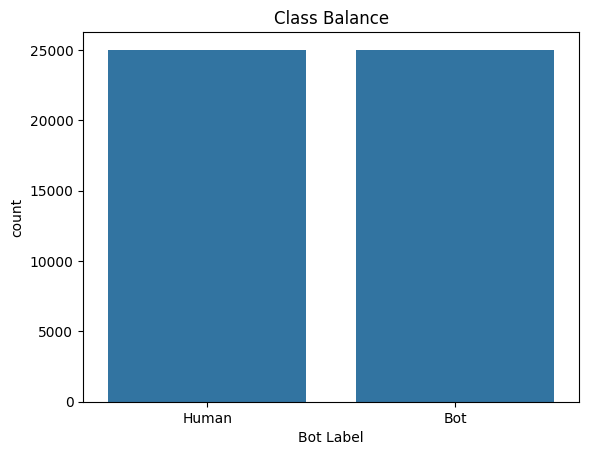

Bot Label
1    0.5
0    0.5
Name: proportion, dtype: float64


In [9]:
ax = sns.countplot(x='Bot Label', data=df)
ax.set_xticklabels(['Human', 'Bot'])
plt.title('Class Balance')
plt.show()
print(df['Bot Label'].value_counts(normalize=True).round(3))


C:\Users\kaavy\AppData\Local\Temp\ipykernel_17904\2892039026.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Human', 'Bot'])
C:\Users\kaavy\AppData\Local\Temp\ipykernel_17904\2892039026.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Human', 'Bot'])
C:\Users\kaavy\AppData\Local\Temp\ipykernel_17904\2892039026.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Human', 'Bot'])


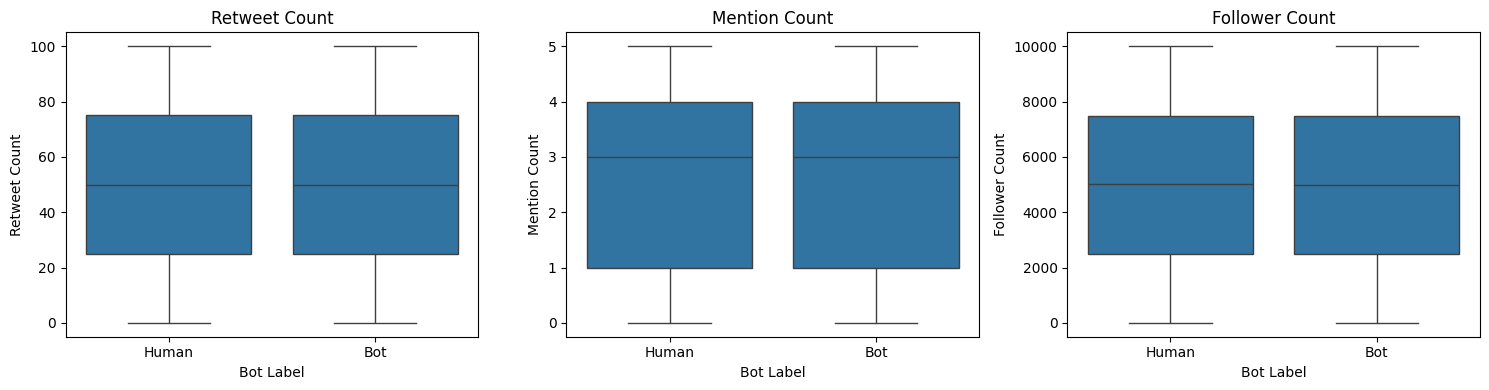

In [10]:
num_cols = ['Retweet Count', 'Mention Count', 'Follower Count']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(x='Bot Label', y=col, data=df, ax=ax)
    ax.set_xticklabels(['Human', 'Bot'])
    ax.set_title(col)
plt.tight_layout()
plt.show()


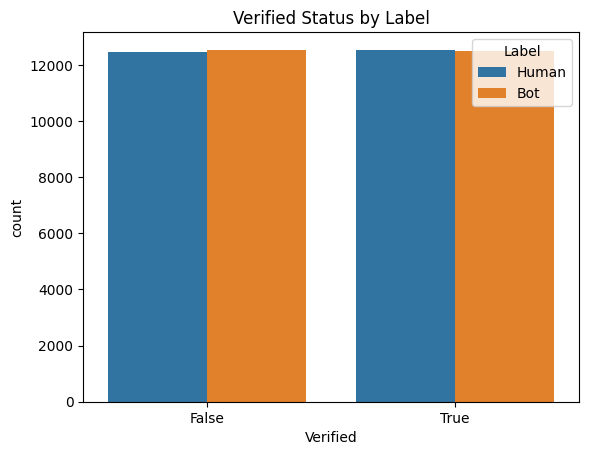

In [11]:
sns.countplot(x='Verified', hue='Bot Label', data=df)
plt.title('Verified Status by Label')
plt.legend(title='Label', labels=['Human', 'Bot'])
plt.show()


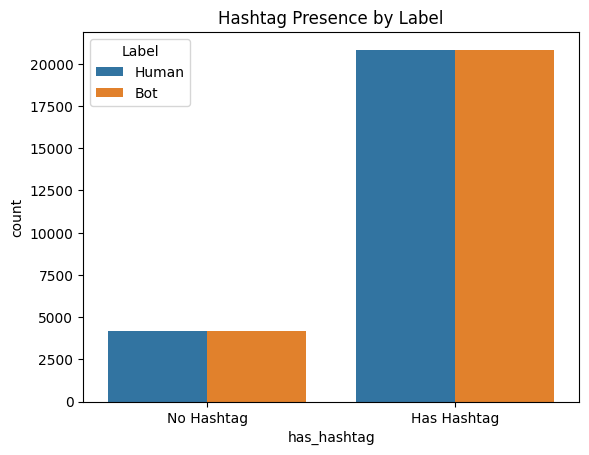

In [12]:
df['has_hashtag'] = df['Hashtags'].notna().astype(int)
sns.countplot(x='has_hashtag', hue='Bot Label', data=df)
plt.title('Hashtag Presence by Label')
plt.xticks([0, 1], ['No Hashtag', 'Has Hashtag'])
plt.legend(title='Label', labels=['Human', 'Bot'])
plt.show()


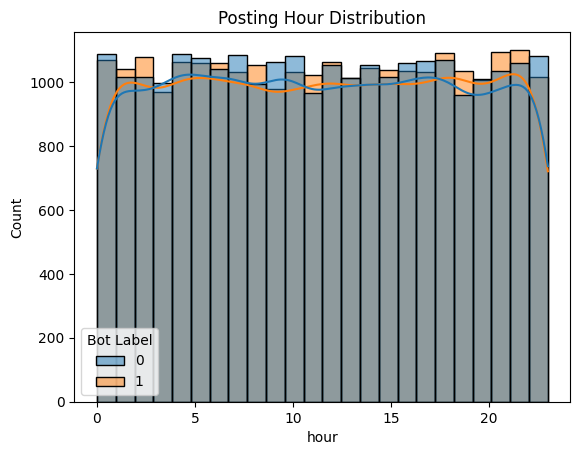

In [13]:
df['Created At'] = pd.to_datetime(df['Created At'])
df['hour'] = df['Created At'].dt.hour
sns.histplot(data=df, x='hour', hue='Bot Label', bins=24, kde=True)
plt.title('Posting Hour Distribution')
plt.show()


In [15]:
df_bots = pd.read_csv('cresci-2017/bot_f.csv')
df_humans = pd.read_csv('cresci-2017/human_f.csv')

print("BOT columns:", df_bots.columns.tolist())
print("HUMAN columns:", df_humans.columns.tolist())
print("\nBot shape:", df_bots.shape)
print("Human shape:", df_humans.shape)
print("\nSample bot row:")
print(df_bots.head(2))


BOT columns: ['userid', 'label', 'friends/follower', 'inf', 'type1', 'type2', 'type3', 'times', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18']
HUMAN columns: ['userid', 'label', 'friends/follower', 'inf', 'type1', 'type2', 'type3', 'times']

Bot shape: (9263, 19)
Human shape: (3474, 8)

Sample bot row:
     userid  label  friends/follower       inf     type1     type2     type3  \
0  80479674      1         12.800000  0.115385  0.896552  0.000000  0.103448   
1  82487179      1          4.148325  0.149360  0.490579  0.348918  0.160502   

   times  Unnamed: 8  Unnamed: 9  Unnamed: 10  Unnamed: 11  Unnamed: 12  \
0      0           1           1            0            0            0   
1      0           1           1            0            0            0   

   Unnamed: 13  Unnamed: 14  Unnamed: 15  Unnamed: 16  Unnamed: 17  \
0            0            1            0   